# AIL7370 : DL4CV
# Assignment 7: Spatio-Temporal Modeling, Latent Representations, and Metric Learning

# Anuj Rajan Lalla (B22AI061)

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE
import random
import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install scikit-image -q

In [2]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Helper Functions

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return running_loss / total, correct / total, all_preds, all_labels

---
# Part 1: Spatio-Temporal Classification with ConvLSTM

## Data Acquisition
### Loading CIFAR-10 as 3D tensors (3, 32, 32)

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_cifar = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

cifar_train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)
cifar_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_cifar)

train_size = int(0.8 * len(cifar_train_full))
val_size = len(cifar_train_full) - train_size
cifar_train, cifar_val = random_split(cifar_train_full, [train_size, val_size])

cifar_classes = cifar_train_full.classes
print("Train samples:", len(cifar_train))
print("Val samples  :", len(cifar_val))
print("Test samples :", len(cifar_test))
print("Classes      :", cifar_classes)

100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]


Train samples: 40000
Val samples  : 10000
Test samples : 10000
Classes      : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Data loaders

In [ ]:
batch_size = 128
cifar_train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=2)
cifar_val_loader   = DataLoader(cifar_val,   batch_size=batch_size, shuffle=False, num_workers=2)
cifar_test_loader  = DataLoader(cifar_test,  batch_size=batch_size, shuffle=False, num_workers=2)

## Visualizing the Patch/Strip Decomposition
Each 3x32x32 CIFAR-10 image is reshaped into 8 timesteps of 3x4x32 horizontal strips. This is the sequence that the ConvLSTM processes from top to bottom.

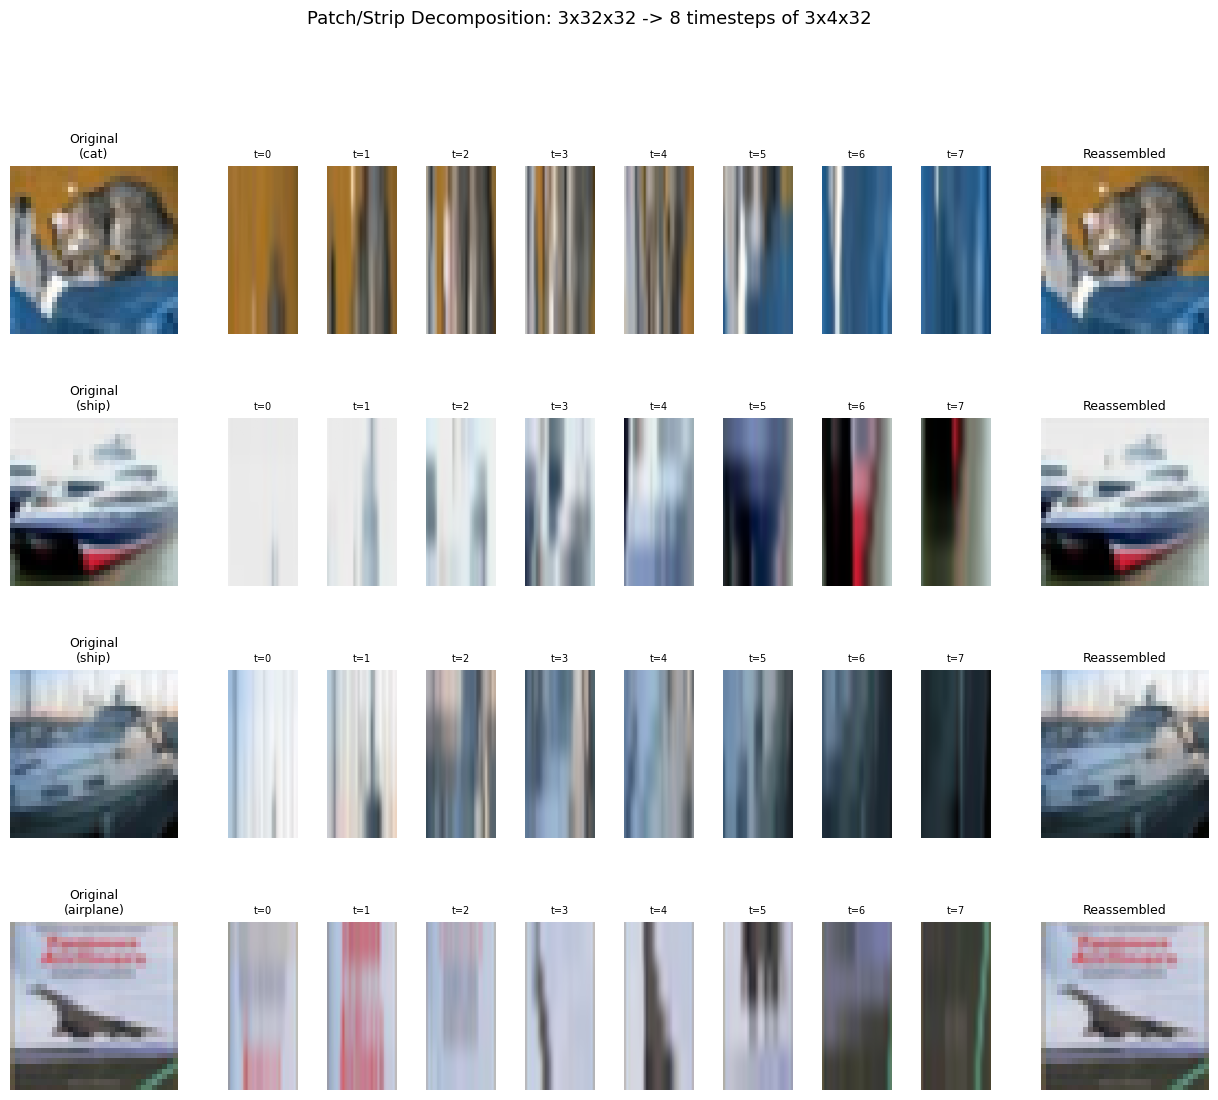

In [ ]:
# Grab 4 sample images
sample_images, sample_labels = [], []
for img, lbl in cifar_test:
    sample_images.append(img)
    sample_labels.append(lbl)
    if len(sample_images) == 4:
        break

num_timesteps = 8
strip_h = 32 // num_timesteps  # 4 pixels per strip

fig = plt.figure(figsize=(16, 12))
outer = gridspec.GridSpec(4, 1, hspace=0.5, figure=fig)

for idx in range(4):
    img_tensor = sample_images[idx]
    label = sample_labels[idx]

    # Unnormalize for display
    img_vis = img_tensor.clone()
    for c in range(3):
        img_vis[c] = img_vis[c] * CIFAR10_STD[c] + CIFAR10_MEAN[c]
    img_vis = img_vis.clamp(0, 1).numpy().transpose(1, 2, 0)

    # Split into 8 strips along the height dimension
    strips = img_tensor.split(strip_h, dim=1)  # split along H -> 8 strips of (3, 4, 32)

    inner = gridspec.GridSpecFromSubplotSpec(1, 10, subplot_spec=outer[idx], wspace=0.3,
                                             width_ratios=[3] + [1]*8 + [3])

    # Original image on the left
    ax_orig = fig.add_subplot(inner[0])
    ax_orig.imshow(img_vis)
    ax_orig.set_title(f"Original\n({cifar_classes[label]})", fontsize=9)
    ax_orig.axis("off")

    # Each strip in the middle
    for t in range(num_timesteps):
        strip_np = strips[t].clone()
        for c in range(3):
            strip_np[c] = strip_np[c] * CIFAR10_STD[c] + CIFAR10_MEAN[c]
        strip_np = strip_np.clamp(0, 1).numpy().transpose(1, 2, 0)  # (4, 32, 3)

        ax_strip = fig.add_subplot(inner[t + 1])
        ax_strip.imshow(strip_np, aspect="auto")
        ax_strip.set_title(f"t={t}", fontsize=7)
        ax_strip.axis("off")

    # Reassembled image on the right (stacking strips back)
    reassembled = torch.cat(strips, dim=1)  # (3, 32, 32)
    re_vis = reassembled.clone()
    for c in range(3):
        re_vis[c] = re_vis[c] * CIFAR10_STD[c] + CIFAR10_MEAN[c]
    re_vis = re_vis.clamp(0, 1).numpy().transpose(1, 2, 0)

    ax_re = fig.add_subplot(inner[9])
    ax_re.imshow(re_vis)
    ax_re.set_title("Reassembled", fontsize=9)
    ax_re.axis("off")

fig.suptitle("Patch/Strip Decomposition: 3x32x32 -> 8 timesteps of 3x4x32", fontsize=13, y=1.01)
plt.show()

## Visualizing the Strip Sequence with Boundary Overlay
Annotating where each strip boundary falls on the original image.

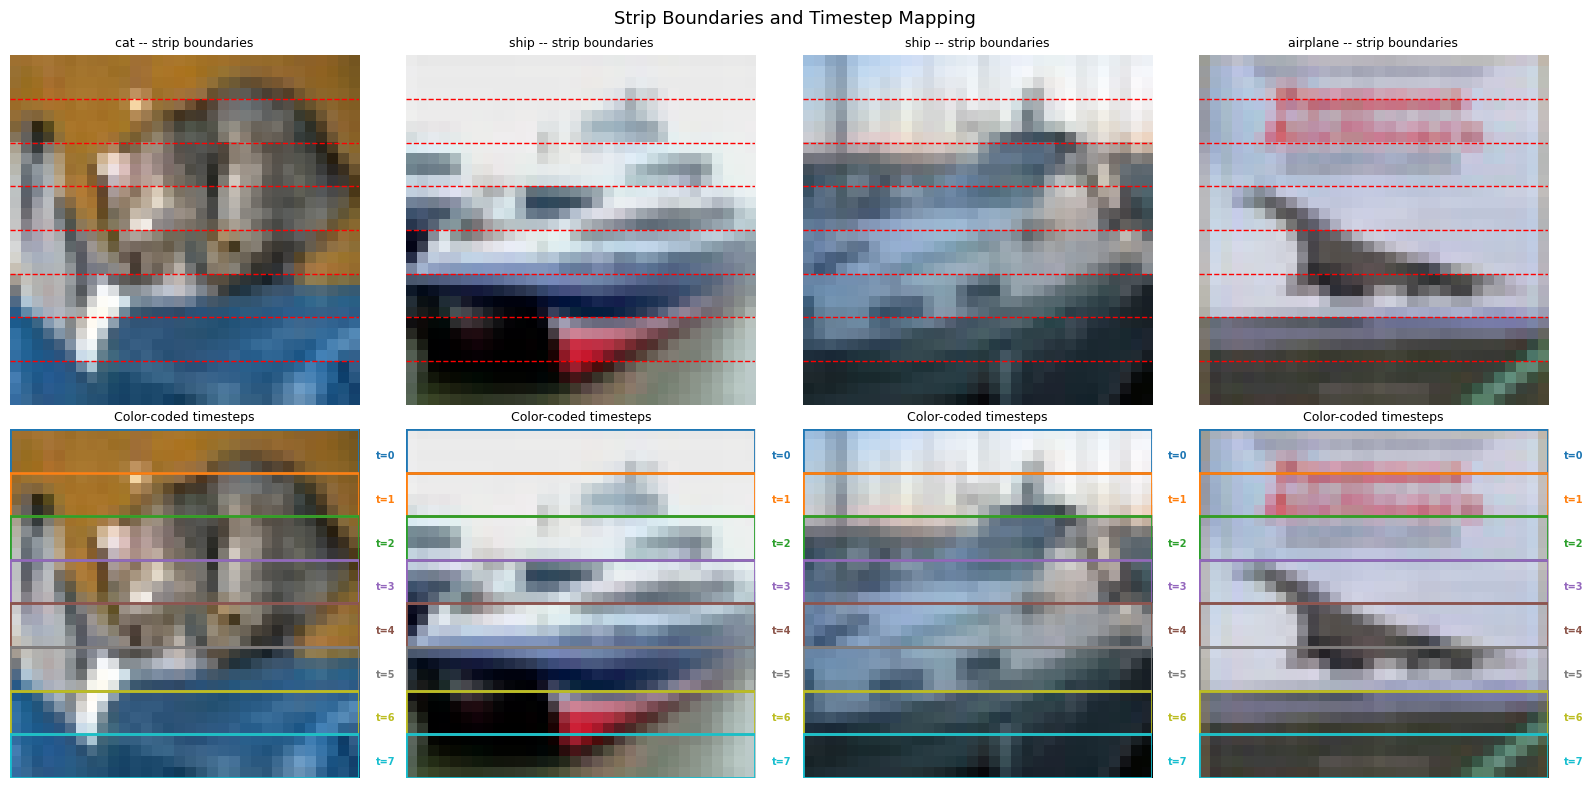

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx in range(4):
    img_tensor = sample_images[idx]
    label = sample_labels[idx]

    # Unnormalize
    img_vis = img_tensor.clone()
    for c in range(3):
        img_vis[c] = img_vis[c] * CIFAR10_STD[c] + CIFAR10_MEAN[c]
    img_vis = img_vis.clamp(0, 1).numpy().transpose(1, 2, 0)

    # Row 1: Original with strip boundary lines
    axes[0][idx].imshow(img_vis)
    for t in range(1, num_timesteps):
        y = t * strip_h
        axes[0][idx].axhline(y=y - 0.5, color="red", linewidth=1.0, linestyle="--")
    axes[0][idx].set_title(f"{cifar_classes[label]} -- strip boundaries", fontsize=9)
    axes[0][idx].axis("off")

    # Row 2: Strips stacked vertically with color-coded borders
    strips = img_tensor.split(strip_h, dim=1)
    stacked = np.zeros((32, 32, 3))
    colors = plt.cm.tab10(np.linspace(0, 1, num_timesteps))
    for t in range(num_timesteps):
        strip_np = strips[t].clone()
        for c_ch in range(3):
            strip_np[c_ch] = strip_np[c_ch] * CIFAR10_STD[c_ch] + CIFAR10_MEAN[c_ch]
        strip_np = strip_np.clamp(0, 1).numpy().transpose(1, 2, 0)
        y_start = t * strip_h
        stacked[y_start:y_start + strip_h, :, :] = strip_np

    axes[1][idx].imshow(stacked)
    for t in range(num_timesteps):
        y_start = t * strip_h
        rect = plt.Rectangle((-0.5, y_start - 0.5), 32, strip_h,
                             linewidth=2, edgecolor=colors[t], facecolor="none")
        axes[1][idx].add_patch(rect)
        axes[1][idx].text(33, y_start + strip_h / 2, f"t={t}", fontsize=7,
                          va="center", color=colors[t], fontweight="bold")
    axes[1][idx].set_title("Color-coded timesteps", fontsize=9)
    axes[1][idx].axis("off")

plt.suptitle("Strip Boundaries and Timestep Mapping", fontsize=13)
plt.tight_layout()
plt.show()

## ConvLSTM Cell
Single ConvLSTM cell that performs convolution-gated recurrence at each timestep.

In [ ]:
class ConvLSTMCell(nn.Module):
    """A single ConvLSTM cell operating on 2D spatial inputs."""

    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2

        # Combined gate convolution: input + hidden -> 4 gates (i, f, o, g)
        self.gates = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding,
        )

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)  # (B, in_ch + hidden_ch, H, W)
        gate_vals = self.gates(combined)

        # Split into four gates
        i, f, o, g = gate_vals.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

    def init_hidden(self, batch_size, height, width, device):
        h = torch.zeros(batch_size, self.hidden_channels, height, width, device=device)
        c = torch.zeros(batch_size, self.hidden_channels, height, width, device=device)
        return h, c

## ConvLSTM Classifier
Reshapes 3x32x32 images into 8 timesteps of 3x4x32 strips (horizontal slicing), then processes sequentially through ConvLSTM layers.

In [ ]:
class ConvLSTMClassifier(nn.Module):
    """
    Splits a 3x32x32 image into 8 timesteps of 3x4x32 horizontal strips.
    Each strip is processed sequentially by stacked ConvLSTM layers.
    The final hidden state is pooled and fed to a classifier head.
    """

    def __init__(self, num_classes=10, hidden_channels=64, num_layers=2, num_timesteps=8):
        super().__init__()
        self.num_timesteps = num_timesteps
        self.strip_h = 32 // num_timesteps  # 4 pixels per strip
        self.num_layers = num_layers

        # Stacked ConvLSTM layers
        self.layers = nn.ModuleList()
        in_ch = 3
        for _ in range(num_layers):
            self.layers.append(ConvLSTMCell(in_ch, hidden_channels, kernel_size=3))
            in_ch = hidden_channels

        self.bn = nn.BatchNorm2d(hidden_channels)

        # Classifier on globally pooled final hidden state
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B = x.size(0)

        # Reshape: (B, 3, 32, 32) -> list of 8 strips, each (B, 3, 4, 32)
        strips = x.split(self.strip_h, dim=2)  # split along height

        # Initialize hidden states for each layer
        strip_h, strip_w = self.strip_h, 32
        states = []
        for layer in self.layers:
            states.append(layer.init_hidden(B, strip_h, strip_w, x.device))

        # Process each timestep through the stack
        for t in range(self.num_timesteps):
            inp = strips[t]
            for l_idx, layer in enumerate(self.layers):
                h, c = layer(inp, states[l_idx])
                states[l_idx] = (h, c)
                inp = h  # output of current layer feeds the next

        # Use the final hidden state of the last layer
        final_h = states[-1][0]  # (B, hidden_channels, 4, 32)
        final_h = self.bn(final_h)
        out = self.classifier(final_h)
        return out


convlstm_model = ConvLSTMClassifier(num_classes=10, hidden_channels=64, num_layers=2).to(device)
print(convlstm_model)
total_params = sum(p.numel() for p in convlstm_model.parameters())
print(f"Total parameters: {total_params:,}")

ConvLSTMClassifier(
  (layers): ModuleList(
    (0): ConvLSTMCell(
      (gates): Conv2d(67, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ConvLSTMCell(
      (gates): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 459,530


## Training the ConvLSTM

In [ ]:
convlstm_model = ConvLSTMClassifier(num_classes=10, hidden_channels=64, num_layers=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(convlstm_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

num_epochs = 15
convlstm_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(convlstm_model, cifar_train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(convlstm_model, cifar_val_loader, criterion, device)
    scheduler.step()

    convlstm_history["train_loss"].append(train_loss)
    convlstm_history["train_acc"].append(train_acc)
    convlstm_history["val_loss"].append(val_loss)
    convlstm_history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch [1/15] Train Loss: 1.7296 Acc: 0.3664 | Val Loss: 1.4901 Acc: 0.4566
Epoch [2/15] Train Loss: 1.4329 Acc: 0.4792 | Val Loss: 1.3454 Acc: 0.5059
Epoch [3/15] Train Loss: 1.2670 Acc: 0.5454 | Val Loss: 1.1796 Acc: 0.5788
Epoch [4/15] Train Loss: 1.1245 Acc: 0.6030 | Val Loss: 1.0778 Acc: 0.6209
Epoch [5/15] Train Loss: 1.0073 Acc: 0.6439 | Val Loss: 1.0453 Acc: 0.6343
Epoch [6/15] Train Loss: 0.9170 Acc: 0.6783 | Val Loss: 0.9624 Acc: 0.6649
Epoch [7/15] Train Loss: 0.8394 Acc: 0.7057 | Val Loss: 0.8768 Acc: 0.6919
Epoch [8/15] Train Loss: 0.7727 Acc: 0.7286 | Val Loss: 0.8776 Acc: 0.6897
Epoch [9/15] Train Loss: 0.6528 Acc: 0.7742 | Val Loss: 0.8144 Acc: 0.7173
Epoch [10/15] Train Loss: 0.5982 Acc: 0.7901 | Val Loss: 0.8399 Acc: 0.7124
Epoch [11/15] Train Loss: 0.5618 Acc: 0.8035 | Val Loss: 0.8538 Acc: 0.7140
Epoch [12/15] Train Loss: 0.5190 Acc: 0.8192 | Val Loss: 0.8551 Acc: 0.7171
Epoch [13/15] Train Loss: 0.4856 Acc: 0.8311 | Val Loss: 0.8640 Acc: 0.7189
Epoch [14/15] Train L

In [ ]:
# Evaluate on test set
_, convlstm_test_acc, convlstm_preds, convlstm_labels = evaluate(
    convlstm_model, cifar_test_loader, criterion, device
)
print(f"ConvLSTM Test Accuracy: {convlstm_test_acc:.4f}\n")
print(classification_report(convlstm_labels, convlstm_preds, target_names=cifar_classes))

ConvLSTM Test Accuracy: 0.7127

              precision    recall  f1-score   support

    airplane       0.73      0.76      0.74      1000
  automobile       0.84      0.82      0.83      1000
        bird       0.61      0.63      0.62      1000
         cat       0.56      0.51      0.54      1000
        deer       0.68      0.62      0.65      1000
         dog       0.61      0.65      0.63      1000
        frog       0.71      0.76      0.73      1000
       horse       0.77      0.72      0.74      1000
        ship       0.78      0.84      0.81      1000
       truck       0.84      0.81      0.82      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



## Visualizing ConvLSTM Hidden States Across Timesteps
Shows how the hidden state evolves as each strip is processed sequentially.

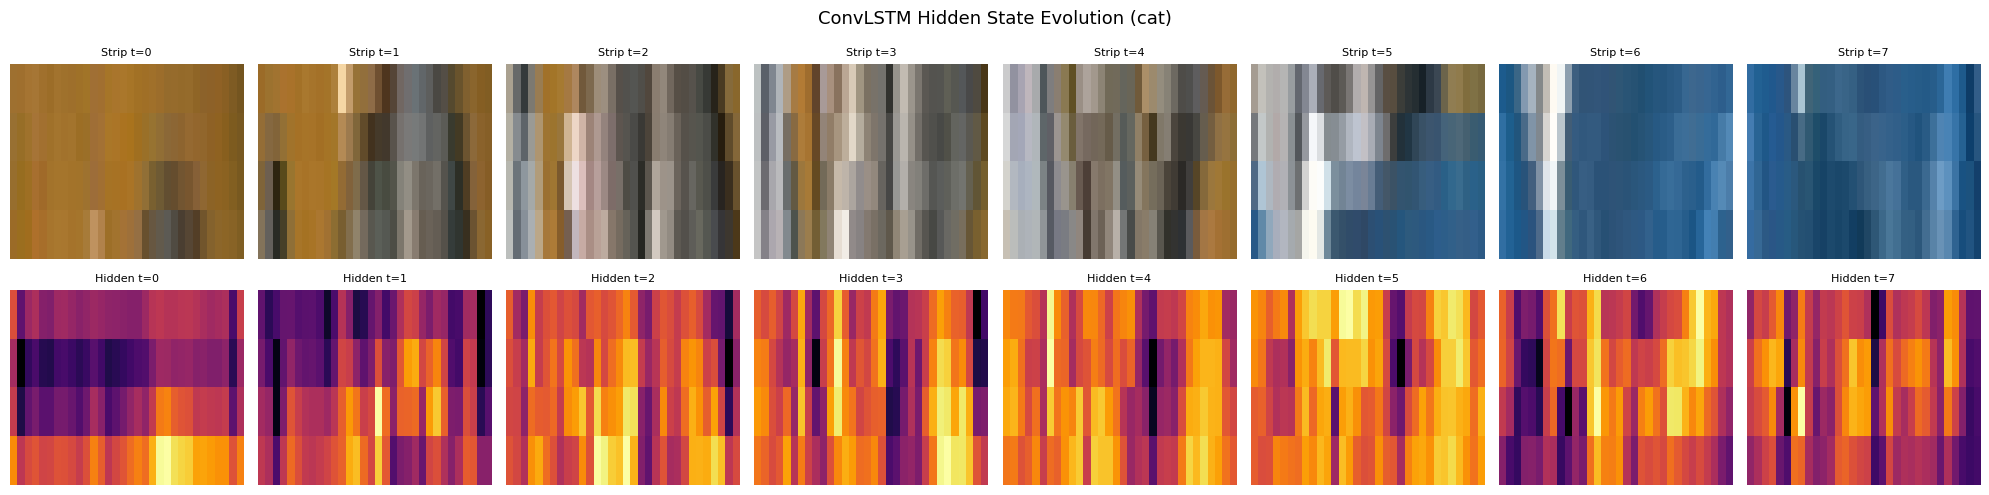

In [ ]:
# Run a single image through the ConvLSTM and capture hidden states at each timestep
convlstm_model.eval()
vis_img = sample_images[0].unsqueeze(0).to(device)  # (1, 3, 32, 32)

with torch.no_grad():
    strips = vis_img.split(convlstm_model.strip_h, dim=2)
    states = []
    for layer in convlstm_model.layers:
        states.append(layer.init_hidden(1, convlstm_model.strip_h, 32, device))

    hidden_snapshots = []  # store hidden state of last layer at each timestep
    for t in range(convlstm_model.num_timesteps):
        inp = strips[t]
        for l_idx, layer in enumerate(convlstm_model.layers):
            h, c = layer(inp, states[l_idx])
            states[l_idx] = (h, c)
            inp = h
        # Snapshot: mean activation across channels -> (4, 32)
        hidden_snapshots.append(states[-1][0][0].cpu().mean(dim=0).numpy())

fig, axes = plt.subplots(2, num_timesteps, figsize=(20, 5))

for t in range(num_timesteps):
    # Row 1: input strip
    strip_np = strips[t][0].cpu().clone()
    for c in range(3):
        strip_np[c] = strip_np[c] * CIFAR10_STD[c] + CIFAR10_MEAN[c]
    strip_np = strip_np.clamp(0, 1).numpy().transpose(1, 2, 0)
    axes[0][t].imshow(strip_np, aspect="auto")
    axes[0][t].set_title(f"Strip t={t}", fontsize=8)
    axes[0][t].axis("off")

    # Row 2: hidden state heatmap
    axes[1][t].imshow(hidden_snapshots[t], cmap="inferno", aspect="auto")
    axes[1][t].set_title(f"Hidden t={t}", fontsize=8)
    axes[1][t].axis("off")

axes[0][0].set_ylabel("Input Strip", fontsize=10)
axes[1][0].set_ylabel("Hidden State", fontsize=10)
plt.suptitle(f"ConvLSTM Hidden State Evolution ({cifar_classes[sample_labels[0]]})", fontsize=13)
plt.tight_layout()
plt.show()

## Standard 3-Layer CNN (Baseline for comparison)

In [ ]:
class StandardCNN(nn.Module):
    """3-layer CNN baseline for CIFAR-10 comparison."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Conv Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32 -> 16x16

            # Conv Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16 -> 8x8

            # Conv Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = StandardCNN().to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

StandardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Drop

## Training the Standard CNN

In [ ]:
cnn_model = StandardCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

num_epochs = 15
cnn_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(cnn_model, cifar_train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(cnn_model, cifar_val_loader, criterion, device)
    scheduler.step()

    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch [1/15] Train Loss: 1.3574 Acc: 0.5063 | Val Loss: 1.0417 Acc: 0.6339
Epoch [2/15] Train Loss: 0.9818 Acc: 0.6532 | Val Loss: 0.9318 Acc: 0.6685
Epoch [3/15] Train Loss: 0.8421 Acc: 0.7035 | Val Loss: 0.8816 Acc: 0.6932
Epoch [4/15] Train Loss: 0.7577 Acc: 0.7339 | Val Loss: 0.8357 Acc: 0.7126
Epoch [5/15] Train Loss: 0.6876 Acc: 0.7587 | Val Loss: 0.7187 Acc: 0.7476
Epoch [6/15] Train Loss: 0.6334 Acc: 0.7774 | Val Loss: 0.7609 Acc: 0.7363
Epoch [7/15] Train Loss: 0.5724 Acc: 0.7997 | Val Loss: 0.7141 Acc: 0.7563
Epoch [8/15] Train Loss: 0.5203 Acc: 0.8175 | Val Loss: 0.6752 Acc: 0.7680
Epoch [9/15] Train Loss: 0.4064 Acc: 0.8556 | Val Loss: 0.6374 Acc: 0.7873
Epoch [10/15] Train Loss: 0.3631 Acc: 0.8722 | Val Loss: 0.6494 Acc: 0.7911
Epoch [11/15] Train Loss: 0.3287 Acc: 0.8839 | Val Loss: 0.7134 Acc: 0.7750
Epoch [12/15] Train Loss: 0.3000 Acc: 0.8938 | Val Loss: 0.6952 Acc: 0.7849
Epoch [13/15] Train Loss: 0.2763 Acc: 0.9008 | Val Loss: 0.6823 Acc: 0.7875
Epoch [14/15] Train L

In [ ]:
# Evaluate on test set
_, cnn_test_acc, cnn_preds, cnn_labels = evaluate(
    cnn_model, cifar_test_loader, criterion, device
)
print(f"Standard CNN Test Accuracy: {cnn_test_acc:.4f}\n")
print(classification_report(cnn_labels, cnn_preds, target_names=cifar_classes))

Standard CNN Test Accuracy: 0.7817

              precision    recall  f1-score   support

    airplane       0.77      0.84      0.80      1000
  automobile       0.90      0.86      0.88      1000
        bird       0.78      0.63      0.70      1000
         cat       0.64      0.57      0.60      1000
        deer       0.67      0.84      0.75      1000
         dog       0.67      0.72      0.69      1000
        frog       0.84      0.81      0.83      1000
       horse       0.80      0.84      0.82      1000
        ship       0.92      0.84      0.88      1000
       truck       0.86      0.87      0.87      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.78     10000
weighted avg       0.79      0.78      0.78     10000



## Comparison: ConvLSTM vs Standard CNN

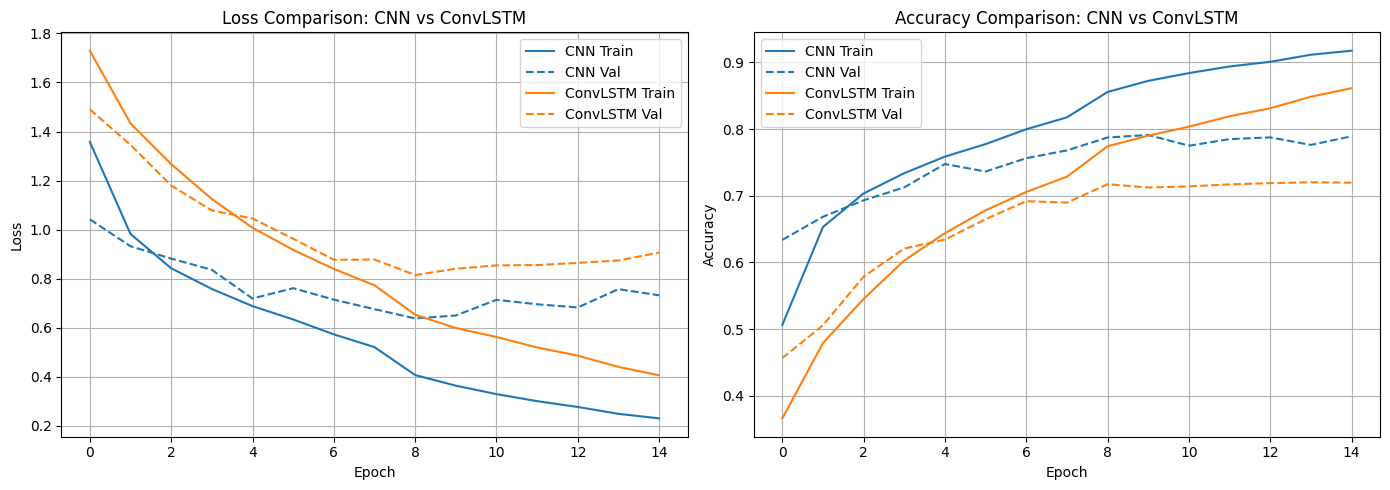


Final Test Accuracy:
  Standard CNN : 0.7817
  ConvLSTM     : 0.7127


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(cnn_history["train_loss"], label="CNN Train", color="tab:blue")
axes[0].plot(cnn_history["val_loss"], "--", label="CNN Val", color="tab:blue")
axes[0].plot(convlstm_history["train_loss"], label="ConvLSTM Train", color="tab:orange")
axes[0].plot(convlstm_history["val_loss"], "--", label="ConvLSTM Val", color="tab:orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Comparison: CNN vs ConvLSTM")
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(cnn_history["train_acc"], label="CNN Train", color="tab:blue")
axes[1].plot(cnn_history["val_acc"], "--", label="CNN Val", color="tab:blue")
axes[1].plot(convlstm_history["train_acc"], label="ConvLSTM Train", color="tab:orange")
axes[1].plot(convlstm_history["val_acc"], "--", label="ConvLSTM Val", color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Comparison: CNN vs ConvLSTM")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy:")
print(f"  Standard CNN : {cnn_test_acc:.4f}")
print(f"  ConvLSTM     : {convlstm_test_acc:.4f}")

## Analysis: ConvLSTM vs Standard CNN

**Why the standard CNN tends to outperform ConvLSTM on CIFAR-10:**

1. **Global spatial context**: Standard convolutions apply kernels across the entire spatial extent of a feature map at every layer. This means a 3-layer CNN quickly builds receptive fields that cover the whole 32x32 image. ConvLSTM, on the other hand, processes the image as a sequence of horizontal strips (each 4x32). The spatial context within each strip is captured by convolutions, but cross-strip (vertical) context can only be communicated through the recurrent hidden state, which creates an information bottleneck.

2. **Sequential processing overhead**: By splitting the image into 8 temporal steps, the ConvLSTM imposes a causal ordering (top to bottom) that does not naturally exist in images. Later strips do have access to information from earlier strips through the hidden state, but earlier strips never see information from later ones. This one-directional information flow is a structural disadvantage for static image classification.

3. **Where ConvLSTM might succeed**: ConvLSTM is designed for problems with genuine temporal or sequential structure (e.g., video frames, time-series radar data). If the CIFAR-10 images had meaningful vertical progression (like a horizon line always at a certain position), the sequential modeling could help. In practice, the relevant features in CIFAR-10 (e.g., wheels of a car, wings of a bird) can appear anywhere in the image, so the sequential bias does not provide an advantage.

---
# Part 2: Autoencoders for Reconstruction & Quality Assessment

## Data Acquisition
### Loading STL-10

In [ ]:
transform_stl = T.Compose([
    T.Resize(64),  # Resize 96x96 -> 64x64 for manageable training
    T.ToTensor(),
])

stl_train = torchvision.datasets.STL10(root="./data", split="train", download=True, transform=transform_stl)
stl_test  = torchvision.datasets.STL10(root="./data", split="test",  download=True, transform=transform_stl)

stl_train_loader = DataLoader(stl_train, batch_size=64, shuffle=True,  num_workers=2)
stl_test_loader  = DataLoader(stl_test,  batch_size=64, shuffle=False, num_workers=2)

print("STL-10 Train samples:", len(stl_train))
print("STL-10 Test samples :", len(stl_test))

100%|██████████| 2.64G/2.64G [02:57<00:00, 14.9MB/s]


STL-10 Train samples: 5000
STL-10 Test samples : 8000


## Convolutional Autoencoder Architecture
Encoder compresses 3x64x64 to a latent bottleneck, Decoder reconstructs back to 3x64x64.

In [ ]:
class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder for STL-10 (64x64).
    Encoder: 3x64x64 -> 256x4x4 (bottleneck)
    Decoder: 256x4x4 -> 3x64x64 (reconstruction)
    """

    def __init__(self, latent_dim=256):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Block 1: 3x64x64 -> 64x32x32
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Block 2: 64x32x32 -> 128x16x16
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Block 3: 128x16x16 -> 256x8x8
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Block 4: 256x8x8 -> 256x4x4 (bottleneck)
            nn.Conv2d(256, latent_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(latent_dim),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Block 1: 256x4x4 -> 256x8x8
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Block 2: 256x8x8 -> 128x16x16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Block 3: 128x16x16 -> 64x32x32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Block 4: 64x32x32 -> 3x64x64
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # Output in [0, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


autoencoder = ConvAutoencoder(latent_dim=256).to(device)
print(autoencoder)
total_params = sum(p.numel() for p in autoencoder.parameters())
print(f"Total parameters: {total_params:,}")

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3):

## Training the Autoencoder
Training strictly on the Train Set using MSE reconstruction loss.

In [ ]:
autoencoder = ConvAutoencoder(latent_dim=256).to(device)
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
mse_loss = nn.MSELoss()

num_epochs = 30
ae_history = {"train_loss": []}

for epoch in range(num_epochs):
    autoencoder.train()
    running_loss = 0.0
    for images, _ in stl_train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        recon, _ = autoencoder(images)
        loss = mse_loss(recon, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(stl_train)
    ae_history["train_loss"].append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Reconstruction Loss: {epoch_loss:.6f}")

Epoch [1/30] Reconstruction Loss: 0.032002
Epoch [2/30] Reconstruction Loss: 0.013725
Epoch [3/30] Reconstruction Loss: 0.010122
Epoch [4/30] Reconstruction Loss: 0.008676
Epoch [5/30] Reconstruction Loss: 0.007511
Epoch [6/30] Reconstruction Loss: 0.006833
Epoch [7/30] Reconstruction Loss: 0.006243
Epoch [8/30] Reconstruction Loss: 0.005755
Epoch [9/30] Reconstruction Loss: 0.005509
Epoch [10/30] Reconstruction Loss: 0.005207
Epoch [11/30] Reconstruction Loss: 0.004781
Epoch [12/30] Reconstruction Loss: 0.004572
Epoch [13/30] Reconstruction Loss: 0.004466
Epoch [14/30] Reconstruction Loss: 0.004358
Epoch [15/30] Reconstruction Loss: 0.003977
Epoch [16/30] Reconstruction Loss: 0.003758
Epoch [17/30] Reconstruction Loss: 0.003671
Epoch [18/30] Reconstruction Loss: 0.003618
Epoch [19/30] Reconstruction Loss: 0.003556
Epoch [20/30] Reconstruction Loss: 0.003459
Epoch [21/30] Reconstruction Loss: 0.003523
Epoch [22/30] Reconstruction Loss: 0.003369
Epoch [23/30] Reconstruction Loss: 0.0032

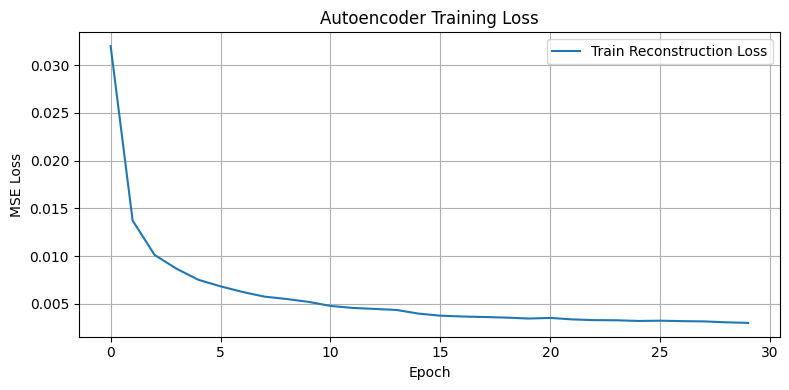

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(ae_history["train_loss"], label="Train Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Reconstruction on the Test Set with PSNR and SSIM

In [ ]:
autoencoder.eval()
all_psnr, all_ssim = [], []

# Collect first batch for visualization
vis_originals, vis_recons, vis_latents = [], [], []

with torch.no_grad():
    for images, _ in stl_test_loader:
        images = images.to(device)
        recon, latent = autoencoder(images)

        # Move to CPU numpy for metric computation
        orig_np = images.cpu().numpy()
        recon_np = recon.cpu().numpy()

        for i in range(orig_np.shape[0]):
            # Convert from (C, H, W) to (H, W, C) for skimage
            orig_img = np.transpose(orig_np[i], (1, 2, 0))
            recon_img = np.clip(np.transpose(recon_np[i], (1, 2, 0)), 0, 1)

            p = psnr(orig_img, recon_img, data_range=1.0)
            s = ssim(orig_img, recon_img, data_range=1.0, channel_axis=2)
            all_psnr.append(p)
            all_ssim.append(s)

        # Save first batch for visualization
        if len(vis_originals) == 0:
            vis_originals = images.cpu()
            vis_recons = recon.cpu()
            vis_latents = latent.cpu()

print(f"Test Set Reconstruction Metrics (over {len(all_psnr)} images):")
print(f"  Mean PSNR : {np.mean(all_psnr):.2f} dB")
print(f"  Std  PSNR : {np.std(all_psnr):.2f} dB")
print(f"  Mean SSIM : {np.mean(all_ssim):.4f}")
print(f"  Std  SSIM : {np.std(all_ssim):.4f}")

Test Set Reconstruction Metrics (over 8000 images):
  Mean PSNR : 25.77 dB
  Std  PSNR : 2.13 dB
  Mean SSIM : 0.8385
  Std  SSIM : 0.0426


## Visualization: Original | Latent Vector Heatmap | Reconstructed Image

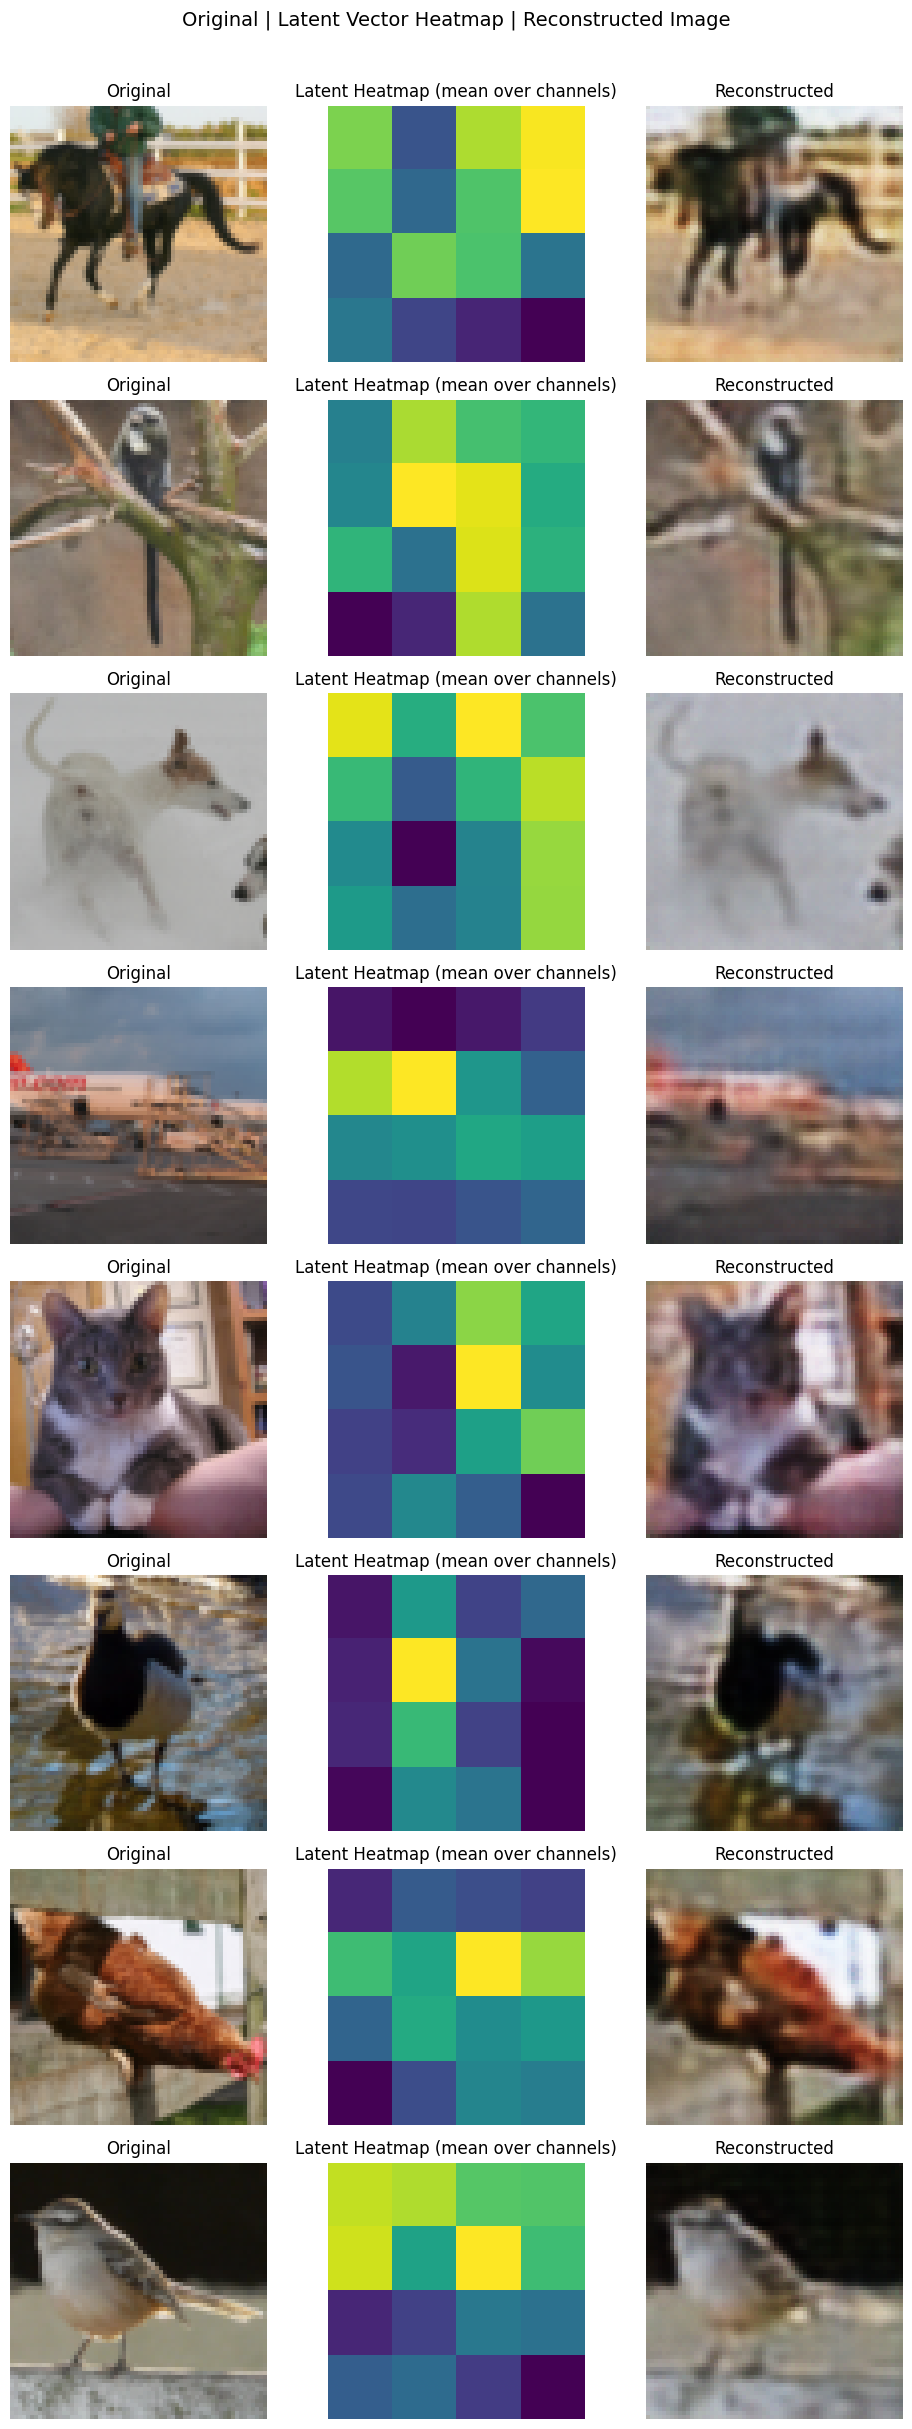

In [ ]:
num_samples = 8
fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 3))

for i in range(num_samples):
    # Original image
    orig = vis_originals[i].numpy().transpose(1, 2, 0)
    orig = np.clip(orig, 0, 1)
    axes[i][0].imshow(orig)
    axes[i][0].set_title("Original")
    axes[i][0].axis("off")

    # Latent vector heatmap
    # The latent tensor is (256, 4, 4); take the mean across channels for a 2D heatmap
    latent_map = vis_latents[i].numpy()  # (256, 4, 4)
    latent_2d = latent_map.mean(axis=0)   # (4, 4)
    axes[i][1].imshow(latent_2d, cmap="viridis", interpolation="nearest")
    axes[i][1].set_title("Latent Heatmap (mean over channels)")
    axes[i][1].axis("off")

    # Reconstructed image
    recon = vis_recons[i].numpy().transpose(1, 2, 0)
    recon = np.clip(recon, 0, 1)
    axes[i][2].imshow(recon)
    axes[i][2].set_title("Reconstructed")
    axes[i][2].axis("off")

plt.suptitle("Original | Latent Vector Heatmap | Reconstructed Image", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## PSNR and SSIM Distribution

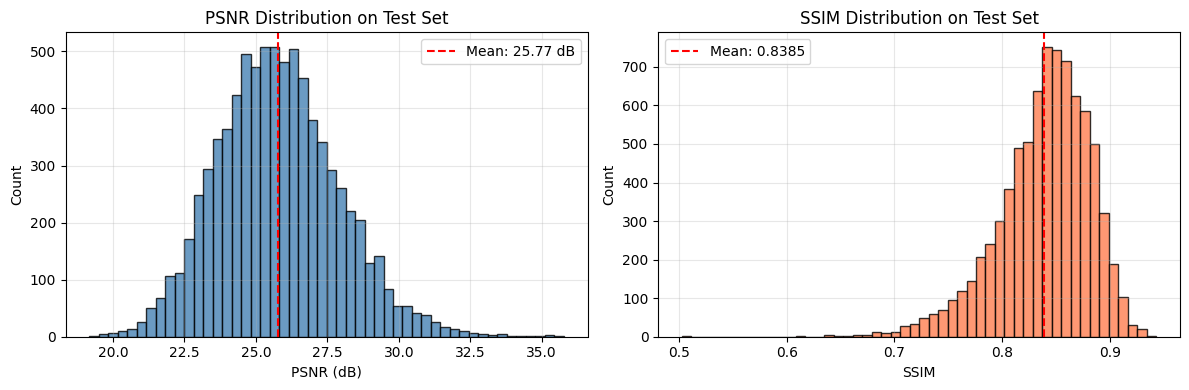

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_psnr, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].axvline(np.mean(all_psnr), color="red", linestyle="--", label=f"Mean: {np.mean(all_psnr):.2f} dB")
axes[0].set_xlabel("PSNR (dB)")
axes[0].set_ylabel("Count")
axes[0].set_title("PSNR Distribution on Test Set")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(all_ssim, bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[1].axvline(np.mean(all_ssim), color="red", linestyle="--", label=f"Mean: {np.mean(all_ssim):.4f}")
axes[1].set_xlabel("SSIM")
axes[1].set_ylabel("Count")
axes[1].set_title("SSIM Distribution on Test Set")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 3: Metric Learning with Siamese Networks

## Data Acquisition
### Loading Fashion-MNIST with pair generation

In [6]:
transform_fmnist = T.Compose([
    T.Resize(32),
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,)),
])

fmnist_train = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_fmnist)
fmnist_test  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform_fmnist)

fmnist_classes = fmnist_train.classes
print("Fashion-MNIST Train:", len(fmnist_train))
print("Fashion-MNIST Test :", len(fmnist_test))
print("Classes:", fmnist_classes)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.4MB/s]


Fashion-MNIST Train: 60000
Fashion-MNIST Test : 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Pair Dataset
Generates positive pairs (same class) and negative pairs (different classes) for contrastive learning.

In [7]:
class SiamesePairDataset(Dataset):
    """
    Generates pairs of images with labels:
      label = 0 for positive pair (same class)
      label = 1 for negative pair (different class)
    """

    def __init__(self, dataset):
        self.dataset = dataset
        self.labels = np.array([dataset[i][1] for i in range(len(dataset))])

        # Build index mapping: class -> list of sample indices
        self.label_to_indices = {}
        for idx, label in enumerate(self.labels):
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)

        self.unique_labels = list(self.label_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        img1, label1 = self.dataset[index]

        # 50% chance positive pair, 50% chance negative pair
        if random.random() < 0.5:
            # Positive pair: pick another sample from the same class
            idx2 = random.choice(self.label_to_indices[label1])
            img2, _ = self.dataset[idx2]
            pair_label = 0  # same class
        else:
            # Negative pair: pick from a different class
            neg_label = random.choice([l for l in self.unique_labels if l != label1])
            idx2 = random.choice(self.label_to_indices[neg_label])
            img2, _ = self.dataset[idx2]
            pair_label = 1  # different class

        return img1, img2, torch.tensor(pair_label, dtype=torch.float32)

In [8]:
siamese_train_dataset = SiamesePairDataset(fmnist_train)
siamese_test_dataset  = SiamesePairDataset(fmnist_test)

siamese_train_loader = DataLoader(siamese_train_dataset, batch_size=128, shuffle=True, num_workers=2)
siamese_test_loader  = DataLoader(siamese_test_dataset,  batch_size=128, shuffle=False, num_workers=2)

# Verify pair generation
img1, img2, pair_label = siamese_train_dataset[0]
print(f"Image 1 shape: {img1.shape}")
print(f"Image 2 shape: {img2.shape}")
print(f"Pair label   : {pair_label.item()} (0=same, 1=different)")

Image 1 shape: torch.Size([1, 32, 32])
Image 2 shape: torch.Size([1, 32, 32])
Pair label   : 1.0 (0=same, 1=different)


## Visualizing Sample Pairs
Showing positive (same class) and negative (different class) pairs from the dataset.

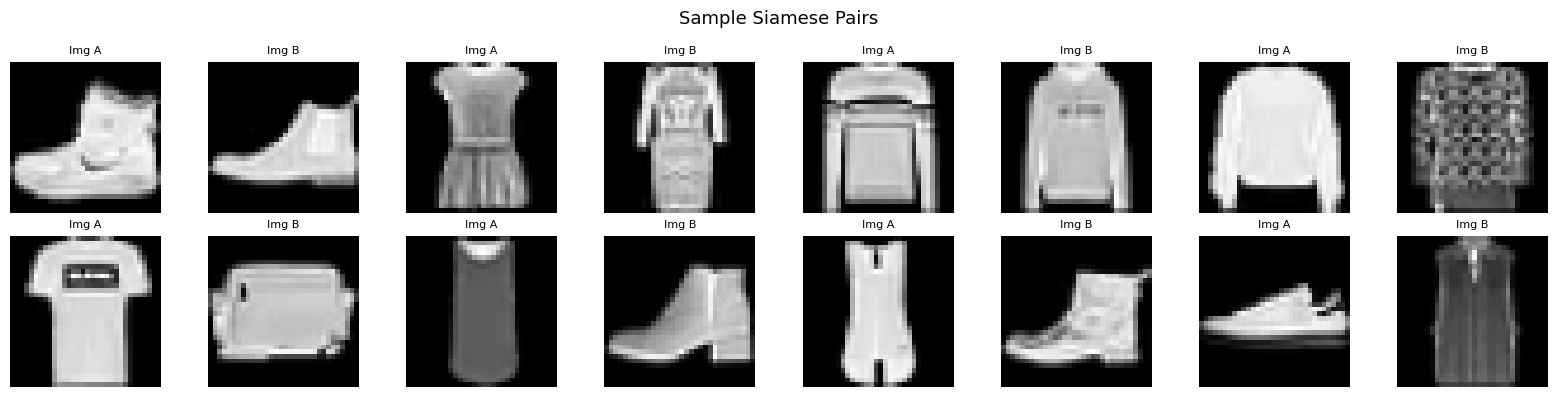

In [9]:
# Collect a few positive and negative pairs for visualization
pos_pairs, neg_pairs = [], []
for i in range(len(siamese_train_dataset)):
    im1, im2, lbl = siamese_train_dataset[i]
    if lbl.item() == 0 and len(pos_pairs) < 4:
        pos_pairs.append((im1, im2))
    elif lbl.item() == 1 and len(neg_pairs) < 4:
        neg_pairs.append((im1, im2))
    if len(pos_pairs) == 4 and len(neg_pairs) == 4:
        break

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(4):
    # Positive pairs (top row)
    im1 = pos_pairs[i][0][0].numpy()  # (1, 32, 32) -> (32, 32)
    im2 = pos_pairs[i][1][0].numpy()
    axes[0][2*i].imshow(im1, cmap="gray")
    axes[0][2*i].set_title("Img A", fontsize=8)
    axes[0][2*i].axis("off")
    axes[0][2*i+1].imshow(im2, cmap="gray")
    axes[0][2*i+1].set_title("Img B", fontsize=8)
    axes[0][2*i+1].axis("off")

    # Negative pairs (bottom row)
    im1 = neg_pairs[i][0][0].numpy()
    im2 = neg_pairs[i][1][0].numpy()
    axes[1][2*i].imshow(im1, cmap="gray")
    axes[1][2*i].set_title("Img A", fontsize=8)
    axes[1][2*i].axis("off")
    axes[1][2*i+1].imshow(im2, cmap="gray")
    axes[1][2*i+1].set_title("Img B", fontsize=8)
    axes[1][2*i+1].axis("off")

axes[0][0].set_ylabel("Positive\n(same)", fontsize=10, rotation=0, labelpad=50)
axes[1][0].set_ylabel("Negative\n(diff)", fontsize=10, rotation=0, labelpad=50)
plt.suptitle("Sample Siamese Pairs", fontsize=13)
plt.tight_layout()
plt.show()

## Siamese Network
Shared-weight backbone (modified ResNet-18) with L2-normalized embeddings.
The original ResNet-18 conv1 (7x7, stride 2) and maxpool aggressively downsample 32x32 inputs to 8x8 immediately, losing spatial detail. Here, conv1 is replaced with a 3x3 stride-1 conv and maxpool is removed to retain resolution through early layers.

In [10]:
class SiameseNetwork(nn.Module):
    """
    Siamese network with a shared ResNet-18 backbone.
    Adapted for 1-channel 32x32 input: smaller conv1, no early maxpool.
    Produces L2-normalized 128-d embeddings per image.
    """

    def __init__(self, embedding_dim=128):
        super().__init__()

        backbone = models.resnet18(weights=None)
        # Replace aggressive 7x7 stride-2 conv with 3x3 stride-1 for small 32x32 inputs
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        # Remove maxpool to avoid losing spatial resolution too early
        backbone.maxpool = nn.Identity()

        self.features = nn.Sequential(*list(backbone.children())[:-1])  # Output: (B, 512, 1, 1)

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embedding_dim),
        )

    def forward_one(self, x):
        """Extract L2-normalized embedding for a single input."""
        feat = self.features(x)
        emb = self.projection(feat)
        emb = F.normalize(emb, p=2, dim=1)  # project onto unit hypersphere
        return emb

    def forward(self, x1, x2):
        """Forward pass for a pair (shared weights)."""
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)
        return emb1, emb2


siamese_model = SiameseNetwork(embedding_dim=128).to(device)
print(siamese_model)
total_params = sum(p.numel() for p in siamese_model.parameters())
print(f"Total parameters: {total_params:,}")

SiameseNetwork(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Identity()
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Con

## Contrastive Loss
Pulls positive pairs closer and pushes negative pairs apart beyond a margin.
With L2-normalized embeddings, distances lie in [0, 2], so a margin of 1.0 is appropriate.

In [11]:
class ContrastiveLoss(nn.Module):
    """
    Contrastive loss function.
    label = 0: same class (pull together)
    label = 1: different class (push apart beyond margin)
    """

    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # Euclidean distance between embeddings
        dist = F.pairwise_distance(emb1, emb2, keepdim=True)

        # Loss: same-class pairs minimize distance, different-class pairs maximize it
        loss = (1 - label) * dist.pow(2) + \
               label * F.relu(self.margin - dist).pow(2)
        return loss.mean()

## Training the Siamese Network

In [12]:
siamese_model = SiameseNetwork(embedding_dim=128).to(device)
contrastive_loss = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(siamese_model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 15
siamese_history = {"train_loss": [], "test_loss": []}

for epoch in range(num_epochs):
    # Training
    siamese_model.train()
    running_loss = 0.0
    for img1, img2, label in siamese_train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        optimizer.zero_grad()
        emb1, emb2 = siamese_model(img1, img2)
        loss = contrastive_loss(emb1, emb2, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * img1.size(0)

    train_loss = running_loss / len(siamese_train_dataset)

    # Evaluation
    siamese_model.eval()
    test_loss_total = 0.0
    with torch.no_grad():
        for img1, img2, label in siamese_test_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            emb1, emb2 = siamese_model(img1, img2)
            loss = contrastive_loss(emb1, emb2, label)
            test_loss_total += loss.item() * img1.size(0)

    test_loss = test_loss_total / len(siamese_test_dataset)
    scheduler.step()

    siamese_history["train_loss"].append(train_loss)
    siamese_history["test_loss"].append(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch [1/15] Train Loss: 0.2546 | Test Loss: 0.2527
Epoch [2/15] Train Loss: 0.2539 | Test Loss: 0.2562
Epoch [3/15] Train Loss: 0.2529 | Test Loss: 0.2524
Epoch [4/15] Train Loss: 0.2527 | Test Loss: 0.2521
Epoch [5/15] Train Loss: 0.2524 | Test Loss: 0.2528
Epoch [6/15] Train Loss: 0.2519 | Test Loss: 0.2516
Epoch [7/15] Train Loss: 0.2516 | Test Loss: 0.2515
Epoch [8/15] Train Loss: 0.2516 | Test Loss: 0.2518
Epoch [9/15] Train Loss: 0.2517 | Test Loss: 0.2517
Epoch [10/15] Train Loss: 0.2516 | Test Loss: 0.2515
Epoch [11/15] Train Loss: 0.2514 | Test Loss: 0.2515
Epoch [12/15] Train Loss: 0.2514 | Test Loss: 0.2513
Epoch [13/15] Train Loss: 0.2513 | Test Loss: 0.2515
Epoch [14/15] Train Loss: 0.2514 | Test Loss: 0.2516
Epoch [15/15] Train Loss: 0.2513 | Test Loss: 0.2513


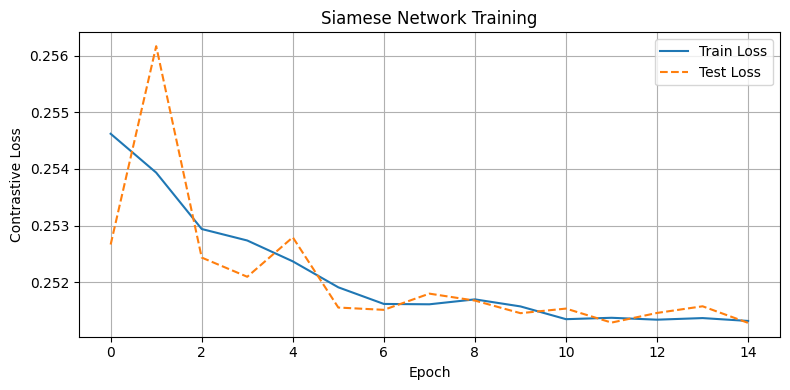

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(siamese_history["train_loss"], label="Train Loss")
plt.plot(siamese_history["test_loss"], "--", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Siamese Network Training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Verification: t-SNE Visualization of Learned Embeddings

In [14]:
# Extract embeddings for the test set
siamese_model.eval()
all_embeddings = []
all_labels_emb = []

with torch.no_grad():
    for images, labels in DataLoader(fmnist_test, batch_size=256, shuffle=False, num_workers=2):
        images = images.to(device)
        embs = siamese_model.forward_one(images)
        all_embeddings.append(embs.cpu().numpy())
        all_labels_emb.append(labels.numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels_emb = np.concatenate(all_labels_emb, axis=0)

print(f"Embeddings shape: {all_embeddings.shape}")
print(f"Labels shape    : {all_labels_emb.shape}")

Embeddings shape: (10000, 128)
Labels shape    : (10000,)


In [15]:
# Subsample for faster t-SNE computation
num_vis = 5000
indices = np.random.choice(len(all_embeddings), num_vis, replace=False)
emb_sub = all_embeddings[indices]
lbl_sub = all_labels_emb[indices]

print(f"Running t-SNE on {num_vis} samples...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
emb_2d = tsne.fit_transform(emb_sub)
print("t-SNE complete.")

Running t-SNE on 5000 samples...
t-SNE complete.


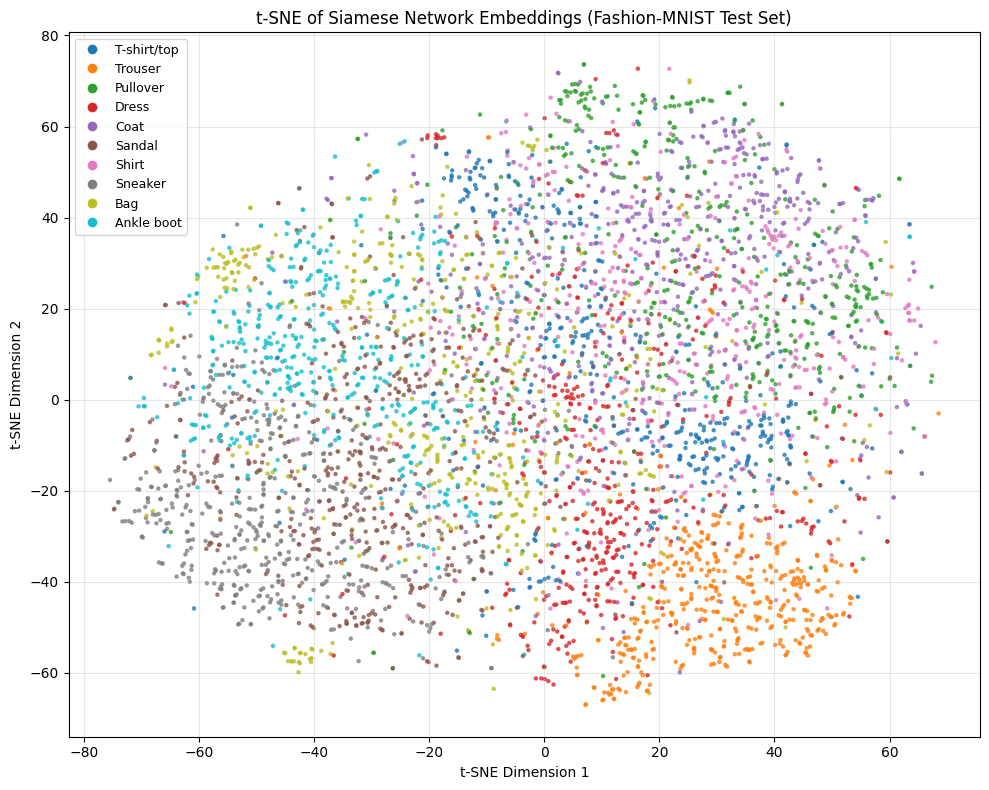

In [16]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=lbl_sub, cmap="tab10", s=5, alpha=0.7
)

# Build legend with class names
handles = []
for i, cls_name in enumerate(fmnist_classes):
    handles.append(plt.Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=plt.cm.tab10(i / 10), markersize=8, label=cls_name
    ))
plt.legend(handles=handles, loc="best", fontsize=9)

plt.title("t-SNE of Siamese Network Embeddings (Fashion-MNIST Test Set)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pair Distance Distribution
Verifying that the embedding space separates positive and negative pairs.

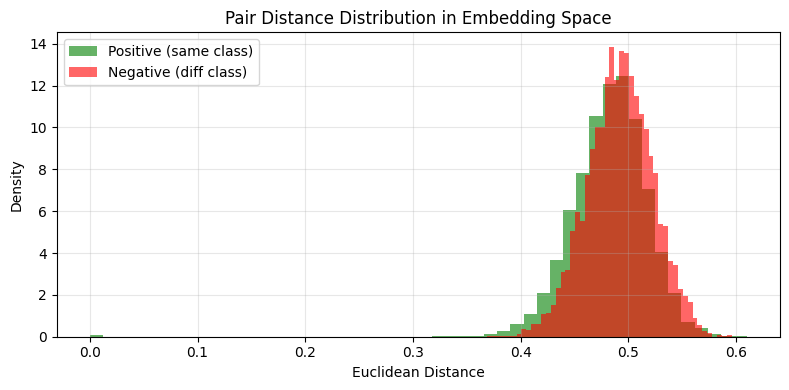

Positive pairs -- Mean dist: 0.4821, Std: 0.0366
Negative pairs -- Mean dist: 0.4921, Std: 0.0304


In [17]:
# Compute distances for positive and negative pairs from the test set
pos_dists, neg_dists = [], []

siamese_model.eval()
with torch.no_grad():
    for img1, img2, label in siamese_test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = siamese_model(img1, img2)
        dists = F.pairwise_distance(emb1, emb2).cpu().numpy()
        labels_np = label.numpy()

        pos_dists.extend(dists[labels_np == 0].tolist())
        neg_dists.extend(dists[labels_np == 1].tolist())

plt.figure(figsize=(8, 4))
plt.hist(pos_dists, bins=50, alpha=0.6, label="Positive (same class)", color="green", density=True)
plt.hist(neg_dists, bins=50, alpha=0.6, label="Negative (diff class)", color="red", density=True)
plt.xlabel("Euclidean Distance")
plt.ylabel("Density")
plt.title("Pair Distance Distribution in Embedding Space")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Positive pairs -- Mean dist: {np.mean(pos_dists):.4f}, Std: {np.std(pos_dists):.4f}")
print(f"Negative pairs -- Mean dist: {np.mean(neg_dists):.4f}, Std: {np.std(neg_dists):.4f}")